In [134]:
import numpy as np
import pandas as pd

**Q-1: You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.**

1. Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi' 'mumbai') as level-0 Index
2. And Sort on row index level-0

In [48]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [49]:
df.unstack(level=0).stack(level=0).swaplevel().swaplevel(axis=1).sort_index(level=0)

cse         ece      cse      ece
            avg_package avg_package students students
delhi  2019           1           9        2       10
       2020           3          11        4       12
       2021           5          13        6       14
       2022           7          15        8       16
mumbai 2019           0           0        0        0
       2020           0           0        0        0
       2021           0           0        0        0
       2022           0           0        0        0

**Q-2: Covid Cases Data Set Problem**

**Make a DataFrame Using both Covid Dataset.**

With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [50]:
confirm = pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/MultiIndexDataFrame/time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/MultiIndexDataFrame/time_series_covid19_deaths_global.csv')

In [51]:
deaths = deaths.melt(id_vars=['Province/State','Country/Region','Lat','Long'] , var_name='date' , value_name='num_of_deaths' )
confirm= confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'] , var_name='date' , value_name='num_of_confirmed_cases' )

In [52]:
df = deaths.merge(confirm , on= ['Province/State','Country/Region','Lat','Long','date'])

In [53]:
df.drop(columns=['Lat'	,'Long'] , inplace=True)

In [54]:
df.set_index(['Country/Region' ,'Province/State' ] ,inplace=True)

In [44]:
df

,,date,num_of_deaths,num_of_confirmed_cases
Country/Region,Province/State,,,
Afghanistan,nan,1/22/20,0,0
Albania,nan,1/22/20,0,0
Algeria,nan,1/22/20,0,0
Andorra,nan,1/22/20,0,0
Angola,nan,1/22/20,0,0
...,...,...,...,...
West Bank and Gaza,nan,1/2/23,5708,703228
Winter Olympics 2022,nan,1/2/23,0,535
Yemen,nan,1/2/23,2159,11945


**Q-3: Show Country with Highest death percent out of confirmed Cases.**

In [58]:
temp_df = df.reset_index().groupby('Country/Region').sum(numeric_only=True)
temp_df.reset_index(inplace=True)
temp_df['death_ratio'] = (temp_df['num_of_deaths'] /temp_df['num_of_confirmed_cases']) * 100
temp_df.sort_values('death_ratio' , ascending=False).head(1)

,Country/Region,num_of_deaths,num_of_confirmed_cases,death_ratio
93,"Korea, North",1404,234,600.0


**Q-4 : Make a dataframe for Pakistan from Covid Data with one extra column representing no of new cases.**

1. Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
2. First day new cases will be NaN or equal to no of cases
3. Say on 12/30/22 No of cases is - 44679608 and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases = 44679608 - 44679382 =

**Note:- Try using shift Function**

Try using the shift function

s = pd.Series([1,2,3,4,5,6])

s #-> [1,2,3,4,5,6]

s.shift(1) #-> [NaN, 1,2,3,4,5]

s.shift(-1) #-> [2,3,4,5,6, NaN]

In [71]:
pak_cases = confirm[confirm['Country/Region'] == 'Pakistan']

In [72]:
pak_cases.reset_index(inplace=True)
pak_cases

,index,Province/State,Country/Region,Lat,Long,date,num_of_confirmed_cases
0,210,NaN,Pakistan,30.3753,69.3451,1/22/20,0
1,499,NaN,Pakistan,30.3753,69.3451,1/23/20,0
2,788,NaN,Pakistan,30.3753,69.3451,1/24/20,0
3,1077,NaN,Pakistan,30.3753,69.3451,1/25/20,0
4,1366,NaN,Pakistan,30.3753,69.3451,1/26/20,0
...,...,...,...,...,...,...,...
1072,310018,NaN,Pakistan,30.3753,69.3451,12/29/22,1575772
1073,310307,NaN,Pakistan,30.3753,69.3451,12/30/22,1575772
1074,310596,NaN,Pakistan,30.3753,69.3451,12/31/22,1575772
1075,310885,NaN,Pakistan,30.3753,69.3451,1/1/23,1575817


In [73]:
new_col = pak_cases['num_of_confirmed_cases'].shift(1)
pak_cases['new_cases'] = pak_cases.num_of_confirmed_cases - new_col

In [74]:
pak_cases

,index,Province/State,Country/Region,Lat,Long,date,num_of_confirmed_cases,new_cases
0,210,NaN,Pakistan,30.3753,69.3451,1/22/20,0,NaN
1,499,NaN,Pakistan,30.3753,69.3451,1/23/20,0,0.0
2,788,NaN,Pakistan,30.3753,69.3451,1/24/20,0,0.0
3,1077,NaN,Pakistan,30.3753,69.3451,1/25/20,0,0.0
4,1366,NaN,Pakistan,30.3753,69.3451,1/26/20,0,0.0
...,...,...,...,...,...,...,...,...
1072,310018,NaN,Pakistan,30.3753,69.3451,12/29/22,1575772,121.0
1073,310307,NaN,Pakistan,30.3753,69.3451,12/30/22,1575772,0.0
1074,310596,NaN,Pakistan,30.3753,69.3451,12/31/22,1575772,0.0
1075,310885,NaN,Pakistan,30.3753,69.3451,1/1/23,1575817,45.0


# Air_Polluated Contries/Cities

**Task:**

1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Turkey and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [124]:
df = pd.read_csv('https://tinyurl.com/2fe6vz4u')

In [125]:
df.drop(columns= 'Unnamed: 0' , inplace=True)
df.set_index(['Country' , 'City/Town'] , inplace=True)

In [97]:
# 1 Find out the name of the city of Pakistan which is most poluted based on PM10.
temp_df = df.loc['Pakistan']

In [101]:
temp_df.sort_values('PM10' , ascending=False).index[0]

'Peshawar'

In [102]:
# Find out the name of the city of India which has minumum pollution level based on PM10.
temp_df.sort_values('PM10').head(1).index[0]

'Faisalabad'

<Axes: >

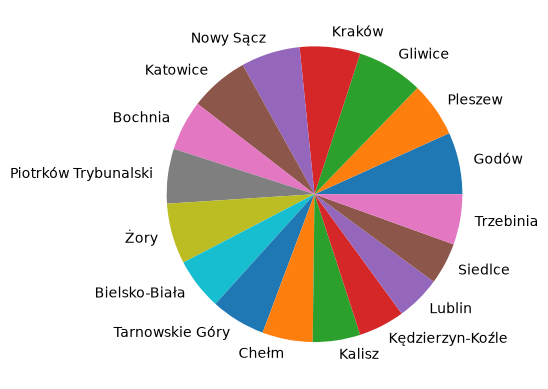

In [103]:
# Make a pie chart based on the column "PM10" of the country Poland.
df_1 = df.loc['Poland']
df_1['PM10'].plot(kind='pie')

<Axes: xlabel='Country,City/Town'>

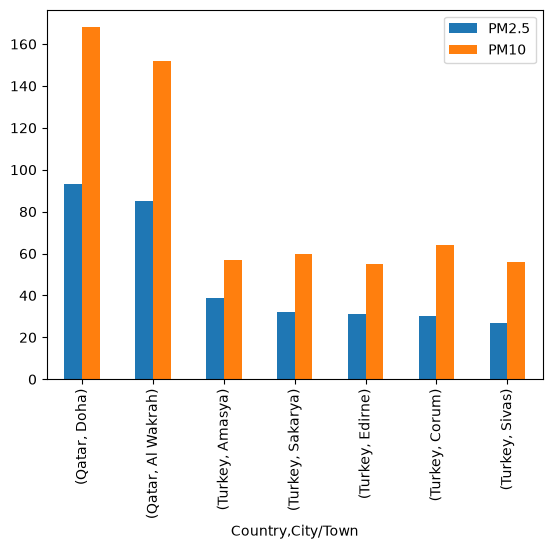

In [113]:
# Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Turkey and Qatar.
df.loc[['Qatar' , 'Turkey']][['PM2.5' ,'PM10']].plot(kind='bar')

In [133]:
# Convert this MultiIndex DataFrame to Series by retaining the informations.
df.stack()

Country  City/Town                         
India    Kanpur     Position                      1
                    Year                       2016
                    PM2.5                       173
                    Temporal coverage          >75%
                    PM10                        319
                                               ... 
Turkey   Sivas      PM2.5                        27
                    Temporal coverage          >75%
                    PM10                         56
                    Temporal coverage.1        >75%
                    Database version (year)    2018
Length: 3500, dtype: object